# Getting started with AudioSeal

This notebook shows a minimal example to get started with AudioSeal. Make sure you install the package from PyPi or from source in editable mode beforehand.

First, let's prepare some example audios into the proper Tensor format using Torchaudio

In [19]:
%%capture

# For the demonstration, we need torchaudio and matplotlib to process example audios and visualize the spectrogram
import sys
!{sys.executable} -m pip install torchaudio soundfile matplotlib

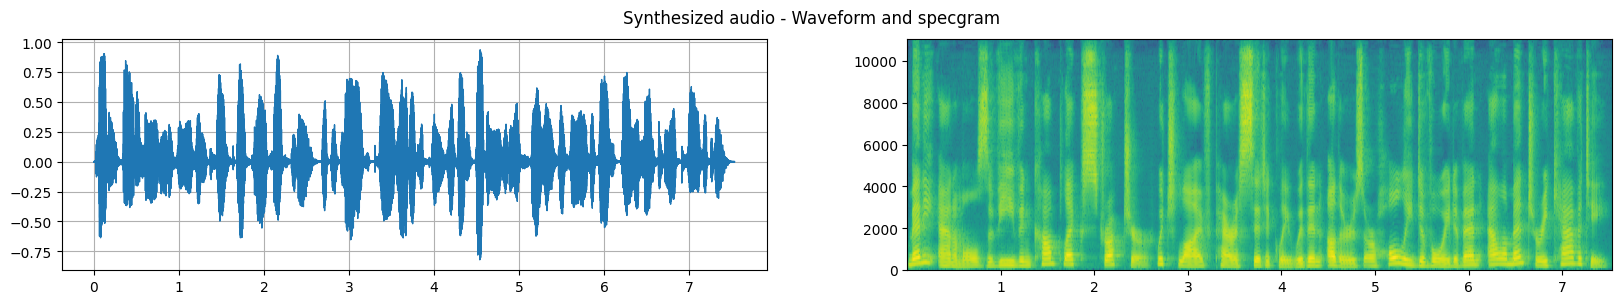

In [20]:
import torch
import torchaudio
import os
from notebook import play_audio, plot_waveform_and_specgram, plot_waveform_and_melspec
audio_path = r'D:/programs/wm/voice.clone/FastSpeech2/output/result/LJSpeech/Many animals of even complex structure which live parasitically within others are wholly devoid of a.wav'

audio, sr = torchaudio.load(audio_path)
plot_waveform_and_specgram(audio, sr, title="Synthesized audio")

In [21]:
play_audio(audio, sr)
import soundfile as sf
sf.write("synthesized.wav", audio.squeeze(0).cpu().numpy(), sr)

In [22]:
from audioseal import AudioSeal
detector = AudioSeal.load_detector(("audioseal_detector_16bits"))

result, message = detector.detect_watermark(audio.unsqueeze(0), sample_rate=sr, message_threshold=0.5)

print(f"\nThis is likely a watermarked audio: {result}")
print(message)


This is likely a watermarked audio: 0.0
tensor([[0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1]], dtype=torch.int32)


In [23]:
pred_prob, message_prob = detector(audio.unsqueeze(0), sample_rate=sr)
print(pred_prob[:, 1, :])

tensor([[0.0013, 0.0013, 0.0013,  ..., 0.0685, 0.0678, 0.0669]],
       grad_fn=<SliceBackward0>)


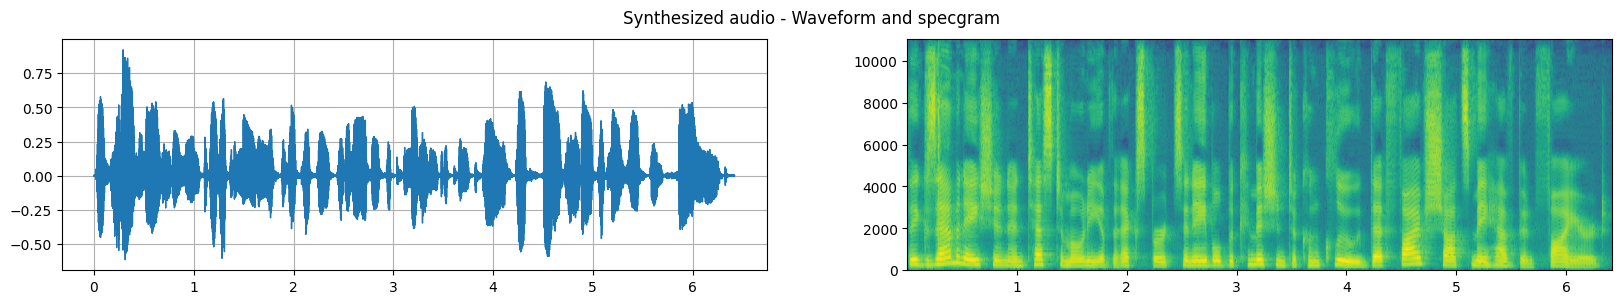

In [24]:
audio_path = r'D:/programs/wm/voice.clone/FastSpeech2/output/result/LJSpeech/The examination and testimony of the experts enabled the Commission to conclude that five shots may .wav'

audio, sr = torchaudio.load(audio_path)
plot_waveform_and_specgram(audio, sr, title="Synthesized audio")

In [25]:
play_audio(audio, sr)

In [26]:
from audioseal import AudioSeal
detector = AudioSeal.load_detector(("audioseal_detector_16bits"))

result, message = detector.detect_watermark(audio.unsqueeze(0), sample_rate=sr, message_threshold=0.5)

print(f"\nThis is likely a watermarked audio: {result}")
print(message)


This is likely a watermarked audio: 0.0
tensor([[0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1]], dtype=torch.int32)


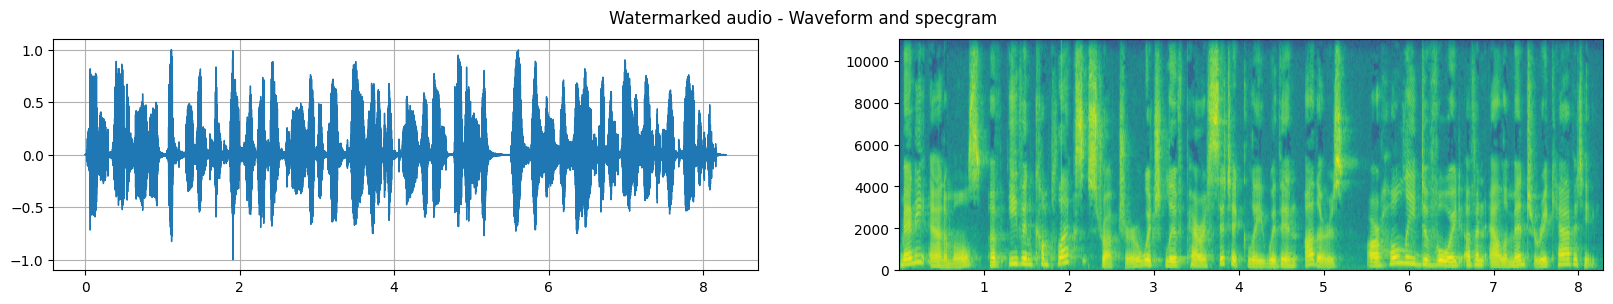

In [27]:
audio_path = r'D:/programs/wm/voice.clone/FastSpeech2/raw_data/LJSpeech/LJSpeech/LJ025-0076.wav'

audio, sr = torchaudio.load(audio_path)
plot_waveform_and_specgram(audio, sr, title="Watermarked audio")

In [28]:
play_audio(audio, sr)
import soundfile as sf
sf.write("watermarked.wav", audio.squeeze(0).cpu().numpy(), sr)

In [29]:
from audioseal import AudioSeal
detector = AudioSeal.load_detector(("audioseal_detector_16bits"))

result, message = detector.detect_watermark(audio.unsqueeze(0), sample_rate=sr, message_threshold=0.5)

print(f"\nThis is likely a watermarked audio: {result}")
print(message)


This is likely a watermarked audio: 1.0
tensor([[1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0]], dtype=torch.int32)


In [30]:
import torch
import torchaudio
import urllib

def download_sample_audio():
    url = "https://keithito.com/LJ-Speech-Dataset/LJ025-0076.wav"
    with open("test.wav", "wb") as f:
        resp = urllib.request.urlopen(url)
        f.write(resp.read())

    wav, sample_rate = torchaudio.load("test.wav")
    return wav, sample_rate

audio, sr = download_sample_audio()

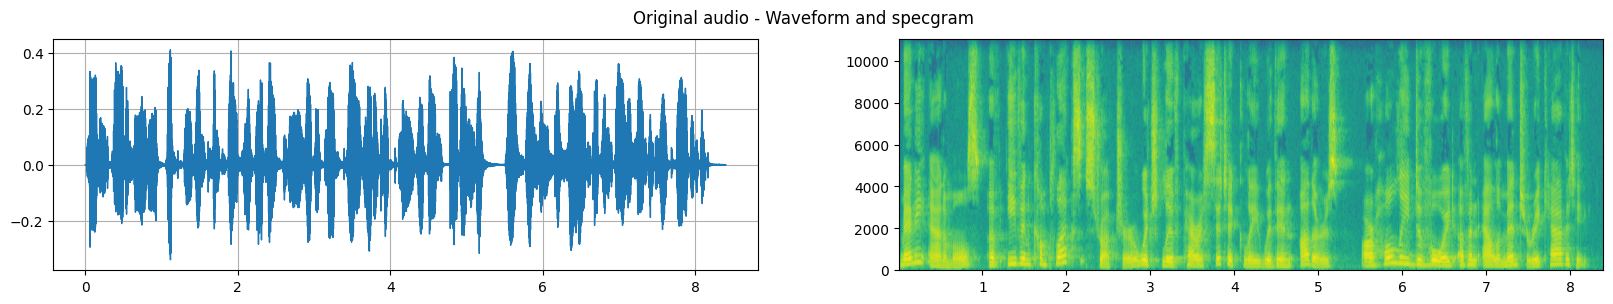

In [31]:
from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (20,3)

from notebook import play_audio, plot_waveform_and_specgram, plot_waveform_and_melspec

plot_waveform_and_specgram(audio, sr, title="Original audio")

In [32]:
play_audio(audio, sr)
import soundfile as sf
sf.write("original.wav", audio.squeeze(0).cpu().numpy(), sr)

In [33]:
from audioseal import AudioSeal
detector = AudioSeal.load_detector(("audioseal_detector_16bits"))

result, message = detector.detect_watermark(audio.unsqueeze(0), sample_rate=sr, message_threshold=0.5)

print(f"\nThis is likely a watermarked audio: {result}")
print(message)


This is likely a watermarked audio: 0.0
tensor([[0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0]], dtype=torch.int32)
